In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('hearing_test.csv')

In [4]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [5]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [6]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='test_result', ylabel='count'>

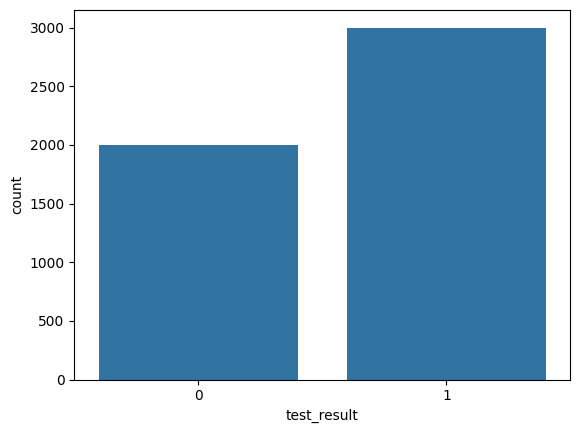

In [7]:
sns.countplot(x='test_result', data=df)

<Axes: xlabel='test_result', ylabel='physical_score'>

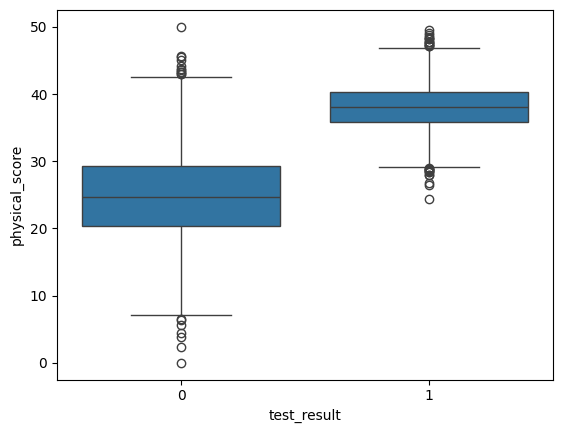

In [8]:
sns.boxplot(x='test_result', y='physical_score', data=df)

<Axes: xlabel='age', ylabel='physical_score'>

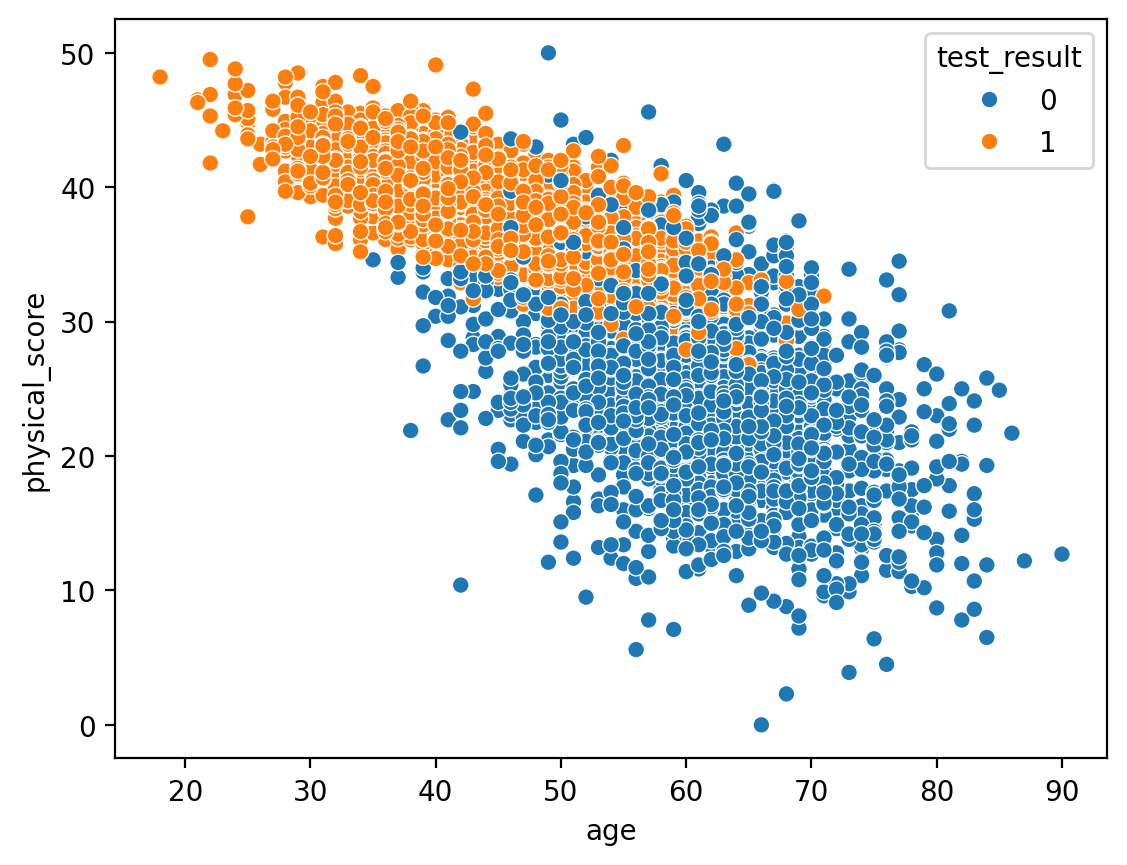

In [9]:
plt.figure(dpi=200)
sns.scatterplot(x='age', y='physical_score', hue='test_result', data=df)

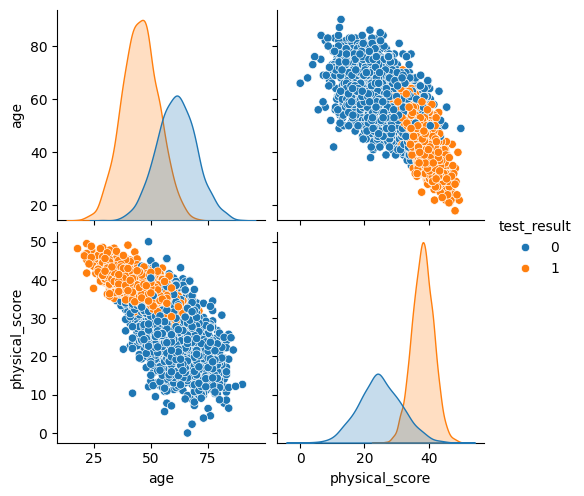

In [10]:
sns.pairplot(df, hue='test_result')

<Axes: >

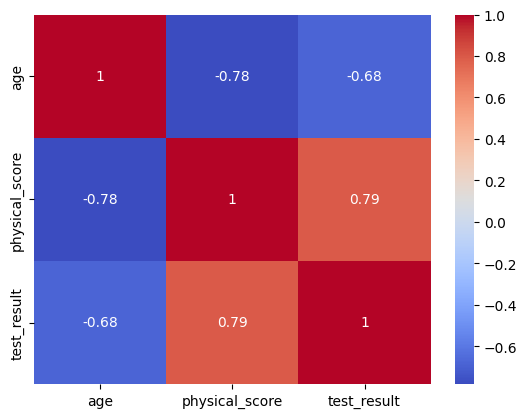

In [11]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='physical_score', ylabel='test_result'>

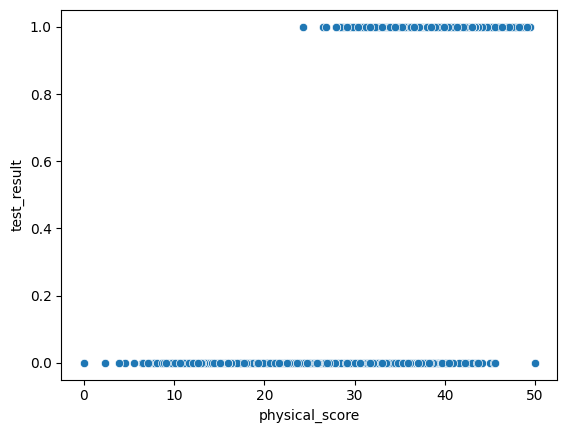

In [12]:
sns.scatterplot(x='physical_score', y='test_result', data=df)

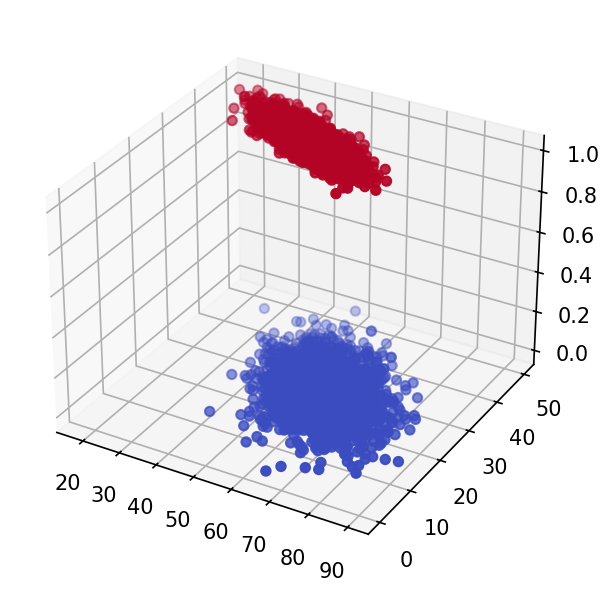

In [13]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['age'], df['physical_score'], df['test_result'], c=df['test_result'], cmap='coolwarm')

In [14]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [15]:
X = df.drop('test_result', axis=1)

In [16]:
y = df['test_result']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [20]:
scaler = StandardScaler()

In [21]:
scaled_X_train = scaler.fit_transform(X_train)

In [22]:
scaled_X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
log_model = LogisticRegression()

In [25]:
log_model.fit(scaled_X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
log_model.coef_ #coefficients tells you how much the dependent variable (output) changes when that independent variable (input) increases by 1 unit, while keeping other variables constant.

array([[-0.9039212 ,  3.48681952]])

In [27]:
y_pred = log_model.predict_proba(scaled_X_test)

In [28]:
y_pred

array([[0.02436668, 0.97563332],
       [0.02672574, 0.97327426],
       [0.9893468 , 0.0106532 ],
       ...,
       [0.02396838, 0.97603162],
       [0.94905149, 0.05094851],
       [0.22356825, 0.77643175]], shape=(1000, 2))

In [29]:
log_model.coef_

array([[-0.9039212 ,  3.48681952]])

In [30]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
y_test

1718    1
2511    1
345     0
2521    1
54      0
       ..
3900    0
3753    1
3582    1
2392    0
3343    1
Name: test_result, Length: 1000, dtype: int64

In [33]:
y_pred = log_model.predict(scaled_X_test)

In [34]:
y_pred

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [36]:
accuracy_score(y_test, y_pred)

0.917

In [ ]:
confusion_matrix(y_test, y_pred) #the confusion matrix shows the number of correct and incorrect predictions made by the model compared to the actual outcomes (target values) in the data.
# In a binary classification problem, it is a 2x2 matrix that summarizes the performance of the model, which includes: 
# True Positives (TP): The number of positive instances that were correctly classified as positive.
# True Negatives (TN): The number of negative instances that were correctly classified as negative.
# False Positives (FP): The number of negative instances that were incorrectly classified as positive (
# False Negatives (FN): The number of positive instances that were incorrectly classified as negative.

array([[332,  56],
       [ 27, 585]])

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay # for cunfusion matrix visualization

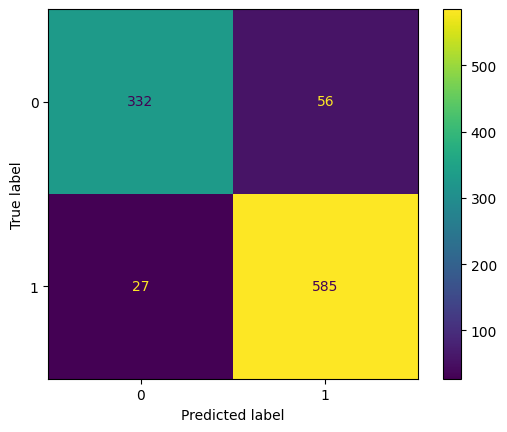

In [46]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

In [47]:
len(y_test)

1000

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       388
           1       0.91      0.96      0.93       612

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.92      0.92      1000



In [50]:
from sklearn.metrics import precision_score, recall_score

In [51]:
precision_score(y_test, y_pred)

0.9126365054602185

In [52]:
recall_score(y_test, y_pred)

0.9558823529411765

In [66]:
from sklearn.metrics import precision_recall_curve, roc_curve, RocCurveDisplay, PrecisionRecallDisplay

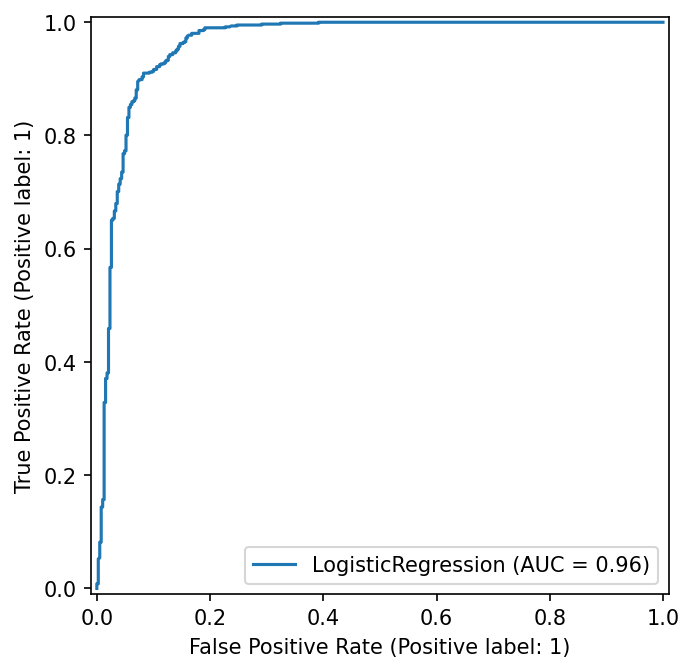

In [68]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test, ax=ax)

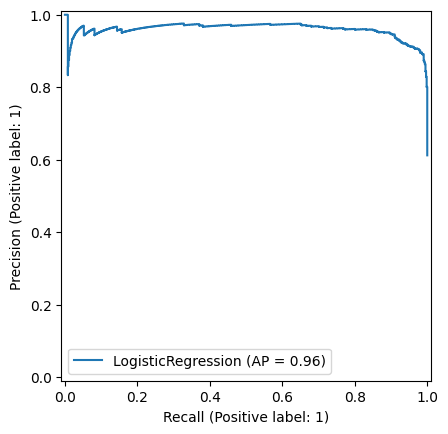

In [70]:
PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test)

In [74]:
log_model.predict_proba(scaled_X_test)[0] #2.4 percent chance of being 0, 97.5 percent chance of being 1

array([0.02436668, 0.97563332])

In [ ]:
y_test[0] #class belonging to class 1

np.int64(1)